In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# ## Упражнения

# Рассмотрим временной ряд ежемесячного индекса розничных продаж в Нидерландах с 1960 по 1995 год.

sales = sm.datasets.get_rdataset("DutchSales", "AER").data
print("Raw data:\n------------------\n", sales.head())

# 1. Выполните необходимую предварительную обработку и преобразуйте данные в формат Prophet.

# Convert decimal year to pandas datetime (similar to CO2 example in main.py)
def convert_decimal_year_to_datetime(decimal_years):
    dates = [(pd.to_datetime(f'{int(year)}-01-01') + pd.to_timedelta((year - int(year)) * 365.25, unit='D')).date()
             for year in decimal_years]
    return dates

# Convert to Prophet format
sales['time'] = convert_decimal_year_to_datetime(sales['time'])
sales.rename(columns={'time': 'ds', 'value': 'y'}, inplace=True)
sales['ds'] = pd.to_datetime(sales['ds'])
print("\nConverted:\n------------------\n", sales.head())

# 2. Разделите данные на обучающую и тестовую выборки, используя первые 90% и последние 10% временного ряда соответственно.

train = sales.iloc[:int(len(sales) * 0.9)].copy()
test = sales.iloc[int(len(sales) * 0.9):].copy()

print(f"\nTrain size: {len(train)}, Test size: {len(test)}")

Raw data:
------------------
           time  value
0  1960.333333     14
1  1960.416667     13
2  1960.500000     15
3  1960.583333     13
4  1960.666667     13

Converted:
------------------
           ds   y
0 1960-05-01  14
1 1960-06-01  13
2 1960-07-01  15
3 1960-08-01  13
4 1960-08-31  13

Train size: 382, Test size: 43


In [3]:

# 3. Постройте модель Prophet на основе данных с использованием линейного тренда и сделайте прогноз на период тестовых данных.

model_linear = Prophet(growth='linear', seasonality_mode='additive', interval_width=0.90)
model_linear.fit(train)

future = pd.DataFrame({'ds': pd.concat([train['ds'], test['ds']])})
forecast_linear = model_linear.predict(future)

# 4. Сделайте прогноз с помощью модели, включающей национальные праздники.

model_holidays = Prophet(holidays=None, growth='linear', seasonality_mode='additive', interval_width=0.90)
model_holidays.add_country_holidays(country_name='NL')
model_holidays.fit(train)
forecast_holidays = model_holidays.predict(future)

# 5. Скорректируйте тренд, изменив параметры `changepoint_range` и `changepoint_prior_scale`. Для каждого параметра попробуйте как минимум два разных значения, отличных от значений по умолчанию.

# Different changepoint_range values
model_range_07 = Prophet(changepoint_range=0.7, growth='linear', seasonality_mode='additive')
model_range_07.fit(train)
forecast_range_07 = model_range_07.predict(future)

model_range_095 = Prophet(changepoint_range=0.95, growth='linear', seasonality_mode='additive')
model_range_095.fit(train)
forecast_range_095 = model_range_095.predict(future)

# Different changepoint_prior_scale values
model_scale_001 = Prophet(changepoint_prior_scale=0.001, growth='linear', seasonality_mode='additive')
model_scale_001.fit(train)
forecast_scale_001 = model_scale_001.predict(future)

model_scale_05 = Prophet(changepoint_prior_scale=0.5, growth='linear', seasonality_mode='additive')
model_scale_05.fit(train)
forecast_scale_05 = model_scale_05.predict(future)

13:34:09 - cmdstanpy - INFO - Chain [1] start processing
13:34:09 - cmdstanpy - INFO - Chain [1] done processing
13:34:09 - cmdstanpy - INFO - Chain [1] start processing
13:34:09 - cmdstanpy - INFO - Chain [1] done processing
13:34:09 - cmdstanpy - INFO - Chain [1] start processing
13:34:09 - cmdstanpy - INFO - Chain [1] done processing
13:34:10 - cmdstanpy - INFO - Chain [1] start processing
13:34:10 - cmdstanpy - INFO - Chain [1] done processing
13:34:10 - cmdstanpy - INFO - Chain [1] start processing
13:34:10 - cmdstanpy - INFO - Chain [1] done processing
13:34:10 - cmdstanpy - INFO - Chain [1] start processing
13:34:10 - cmdstanpy - INFO - Chain [1] done processing


In [4]:

# 6. Сделайте прогнозы с помощью модели с логистическим трендом.

# Determine carrying capacity (cap) based on the data
cap = train['y'].max() * 1.1  # 10% above max observed value

train_log = train.copy()
train_log['cap'] = cap

future_log = future.copy()
future_log['cap'] = cap

model_logistic = Prophet(growth='logistic', seasonality_mode='additive', interval_width=0.90)
model_logistic.fit(train_log)
forecast_logistic = model_logistic.predict(future_log)


13:34:10 - cmdstanpy - INFO - Chain [1] start processing
13:34:10 - cmdstanpy - INFO - Chain [1] done processing



Model Comparison (MSE and MAPE on Test Data)
Linear                              | MSE:      35.6542 | MAPE:   4.4397%
Holidays (NL)                       | MSE:      34.3457 | MAPE:   4.3554%
changepoint_range=0.7               | MSE:      48.5815 | MAPE:   4.9512%
changepoint_range=0.95              | MSE:      72.2272 | MAPE:   6.7593%
changepoint_prior_scale=0.001       | MSE:      38.7685 | MAPE:   4.4405%
changepoint_prior_scale=0.5         | MSE:      40.9288 | MAPE:   4.8370%
Logistic                            | MSE:      73.4681 | MAPE:   6.3706%

Best model by MSE: Holidays (NL)
Best model by MAPE: Holidays (NL)


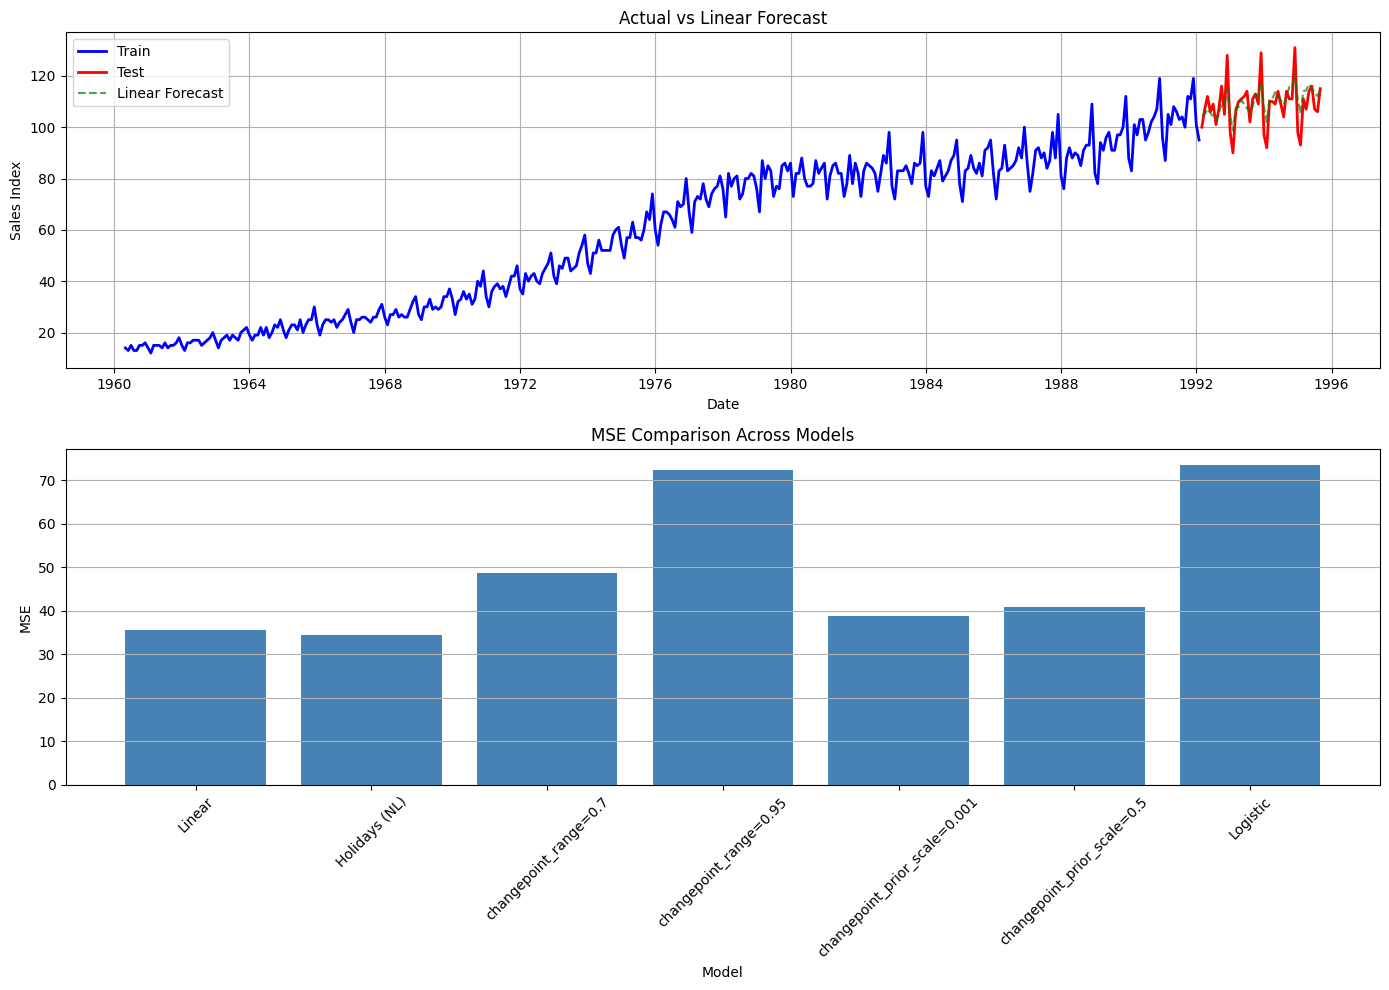


Done!


In [5]:

# 7. Сравните производительность моделей, полученных на шагах 3-6, по показателям MSE и MAPE на тестовых данных.

def calculate_mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)

def calculate_mape(actual, predicted):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# Get test predictions (only for test period)
test_indices = future['ds'].isin(test['ds'])
y_test = test['y'].values

models_results = {
    'Linear': forecast_linear['yhat'][test_indices].values,
    'Holidays (NL)': forecast_holidays['yhat'][test_indices].values,
    'changepoint_range=0.7': forecast_range_07['yhat'][test_indices].values,
    'changepoint_range=0.95': forecast_range_095['yhat'][test_indices].values,
    'changepoint_prior_scale=0.001': forecast_scale_001['yhat'][test_indices].values,
    'changepoint_prior_scale=0.5': forecast_scale_05['yhat'][test_indices].values,
    'Logistic': forecast_logistic['yhat'][test_indices].values,
}

print("\n" + "="*60)
print("Model Comparison (MSE and MAPE on Test Data)")
print("="*60)

results = []
for name, predictions in models_results.items():
    mse = calculate_mse(y_test, predictions)
    mape = calculate_mape(y_test, predictions)
    results.append({'Model': name, 'MSE': mse, 'MAPE': mape})
    print(f"{name:35} | MSE: {mse:12.4f} | MAPE: {mape:8.4f}%")

results_df = pd.DataFrame(results)
print("\nBest model by MSE:", results_df.loc[results_df['MSE'].idxmin(), 'Model'])
print("Best model by MAPE:", results_df.loc[results_df['MAPE'].idxmin(), 'Model'])

# Plot comparisons
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot actual vs predictions
axes[0].plot(train['ds'], train['y'], 'b-', label='Train', linewidth=2)
axes[0].plot(test['ds'], test['y'], 'r-', label='Test', linewidth=2)
axes[0].plot(future['ds'][test_indices], forecast_linear['yhat'][test_indices], 'g--', label='Linear Forecast', alpha=0.7)
axes[0].set_title('Actual vs Linear Forecast')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales Index')
axes[0].legend()
axes[0].grid(True)

# Plot MSE comparison
axes[1].bar(results_df['Model'], results_df['MSE'], color='steelblue')
axes[1].set_title('MSE Comparison Across Models')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

print("\nDone!")